# Actividad 4 — Autocorrelación Espacial (Elecciones Chile 2025)

**Curso:** Análisis de Datos Espaciales · USM
**Duración:** ~60 minutos
**Datos:** Resultados segunda vuelta presidencial 2025, 52 comunas de la Región Metropolitana
**Variable principal:** `Pct_Kast` (% de votos Kast por comuna)

En esta actividad aplicarás los cuatro estadísticos de **autocorrelación espacial global** vistos en la clase 4 al voto presidencial chileno de 2025 en la RM. En cada ejercicio se te pide **calcular** el estadístico y **interpretar** qué dice sobre el patrón espacial del voto.

Al final de cada ejercicio hay un espacio `**Respuesta:**` — escribe ahí tu interpretación con tus propias palabras, no basta con pegar el número.

---


## Setup — Carga de datos

Las siguientes celdas cargan los datos y construyen la cartografía. **Ejecútalas sin modificarlas** antes de empezar los ejercicios.

In [1]:
# Gráficos
import matplotlib.pyplot as plt
import seaborn
import splot
from splot.esda import plot_moran
import contextily

# Análisis
import geopandas
import pandas
import esda
from libpysal import weights
from numpy.random import seed
import numpy as np

In [2]:
# Cargar resultados electorales de la segunda vuelta 2025 (RM)
elec = pandas.read_csv("D:/TrabajosVsCode/geodata/datos/external/elecciones2025/resultados_2v_rm.csv")
elec.head()

,NOM_COMUNA,Pct_Kast,Pct_Jara,Ganador
0,ALHUÉ,62.3,37.7,Kast
1,BUIN,58.4,41.6,Kast
2,CALERA DE TANGO,59.1,40.9,Kast
3,CERRILLOS,52.8,47.2,Kast
4,CERRO NAVIA,42.3,57.7,Jara


In [3]:
# Cargar geometrías de comunas de la RM (Censo 2017)
comunas = geopandas.read_file(
    "D:/TrabajosVsCode/geodata\\datos\\external\\censo2017\\R13\\COMUNA_C17.shp"
)
comunas.head()

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry
0,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,PAINE,1.625330,0.066035,"POLYGON ((-70.61889 -33.73808, -70.61811 -33.7..."
1,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,BUIN,0.884164,0.021166,"POLYGON ((-70.63192 -33.64634, -70.63207 -33.6..."
2,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,PUDAHUEL,0.720176,0.019124,"POLYGON ((-70.78914 -33.36153, -70.78824 -33.3..."
3,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,CERRO NAVIA,0.170180,0.001076,"POLYGON ((-70.71927 -33.41334, -70.71888 -33.4..."
4,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,COLINA,1.692007,0.093820,"POLYGON ((-70.5963 -32.95138, -70.59673 -32.95..."


In [4]:
# Unir datos electorales con geometrías por nombre de comuna
db = comunas.merge(elec, on="NOM_COMUNA", how="inner")

# Reproyectar a EPSG:3857 (Web Mercator, para usar basemaps)
db = db.to_crs(epsg=3857)

print(f"Comunas con datos: {len(db)} de {len(comunas)}")
db[["NOM_COMUNA", "Pct_Kast", "Pct_Jara", "Ganador"]].head(10)

Comunas con datos: 52 de 52


,NOM_COMUNA,Pct_Kast,Pct_Jara,Ganador
0,PAINE,58.9,41.1,Kast
1,BUIN,58.4,41.6,Kast
2,PUDAHUEL,48.6,51.4,Jara
3,CERRO NAVIA,42.3,57.7,Jara
4,COLINA,57.6,42.4,Kast
5,TILTIL,57.3,42.7,Kast
6,LAMPA,56.8,43.2,Kast
7,HUECHURABA,51.8,48.2,Kast
8,CONCHALÍ,47.4,52.6,Jara
9,MARÍA PINTO,63.1,36.9,Kast


---
## Ejercicio 1 — Mapa coroplético y matriz de pesos (10 min)

**1.1** Construye un **mapa coroplético** del `Pct_Kast` con esquema de clasificación `Quantiles` y 5 clases, usando una paleta divergente (ej: `coolwarm` o `RdBu_r`) o una secuencial. Agrega título.


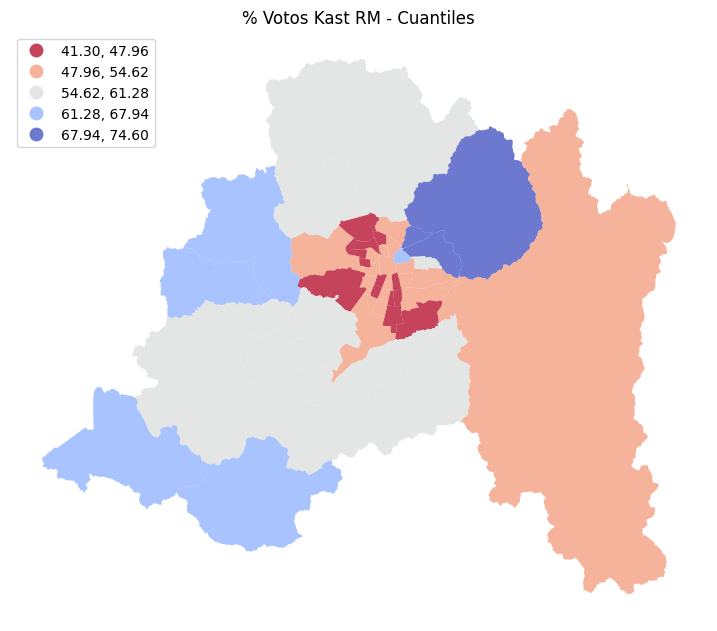

In [5]:
# Tu código aquí
f, ax = plt.subplots(1, figsize=(9, 9))
db.plot(
    column="Pct_Kast",
    cmap="coolwarm_r",
    scheme="EqualInterval",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=ax,
)
ax.set_axis_off()
plt.title("% Votos Kast RM - Cuantiles")
plt.show()

**1.2** Construye una **matriz de pesos espaciales** por k-vecinos más cercanos con `k=8` usando `weights.KNN.from_dataframe` con `ids="NOM_COMUNA"`. Estandarízala por filas (`w.transform = "R"`).


In [6]:
# Tu código aquí
w = weights.KNN.from_dataframe(db, k=8, ids = "NOM_COMUNA")
w.transform = "R"

**1.3** Observando el mapa: ¿detectas a simple vista algún patrón espacial en el voto Kast? ¿Qué zonas de la RM parecen agrupar valores altos y cuáles valores bajos?

**Respuesta:** En zonas lejanas a stgo gana Kast como Melipilla, Paine, Curacavi, etc. Comunas de la zona oriente como Vitacura, Las Condes, Lo Barnechea agrupan los valores más altos. Las comunas con valores bajos son Pedro Aguirre Cerda, Cerro Navia y Lo Espejo.


---
## Ejercicio 2 — Rezago espacial (10 min)

**2.1** Calcula el **rezago espacial** de `Pct_Kast` usando `weights.lag_spatial(w, ...)` y guárdalo como columna `Pct_Kast_lag`.


In [7]:
# Tu código aquí
db["Pct_Kast_lag"] = weights.spatial_lag.lag_spatial(w, db["Pct_Kast"])

**2.2** Elige dos comunas con voto Kast contrastante (una alta, una baja) y compara su valor observado con el rezago espacial de sus vecinas. Imprime los resultados.


In [8]:
# Tu código aquí
# Vitacura - Gana Kast
# Pedro Aguirre Cerda - Gana Jara
db_KastWin = db[db['NOM_COMUNA'] == "VITACURA"]
db_JaraWin = db[db['NOM_COMUNA'] == "PEDRO AGUIRRE CERDA"]
db_JaraWin

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry,Pct_Kast,Pct_Jara,Ganador,Pct_Kast_lag
14,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13121,PEDRO AGUIRRE CERDA,0.127968,0.00085,"POLYGON ((-7865348.447 -3958969.934, -7865358....",41.3,58.7,Jara,50.35


In [9]:
db_KastWin

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry,Pct_Kast,Pct_Jara,Ganador,Pct_Kast_lag
25,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13132,VITACURA,0.262867,0.002754,"POLYGON ((-7856256.346 -3942428.722, -7856251....",74.6,25.4,Kast,55.8


**2.3** Dibuja dos mapas lado a lado: el `Pct_Kast` original y el `Pct_Kast_lag`. Usa la misma escala de color.


Text(0.5, 1.0, 'Kast Lag')

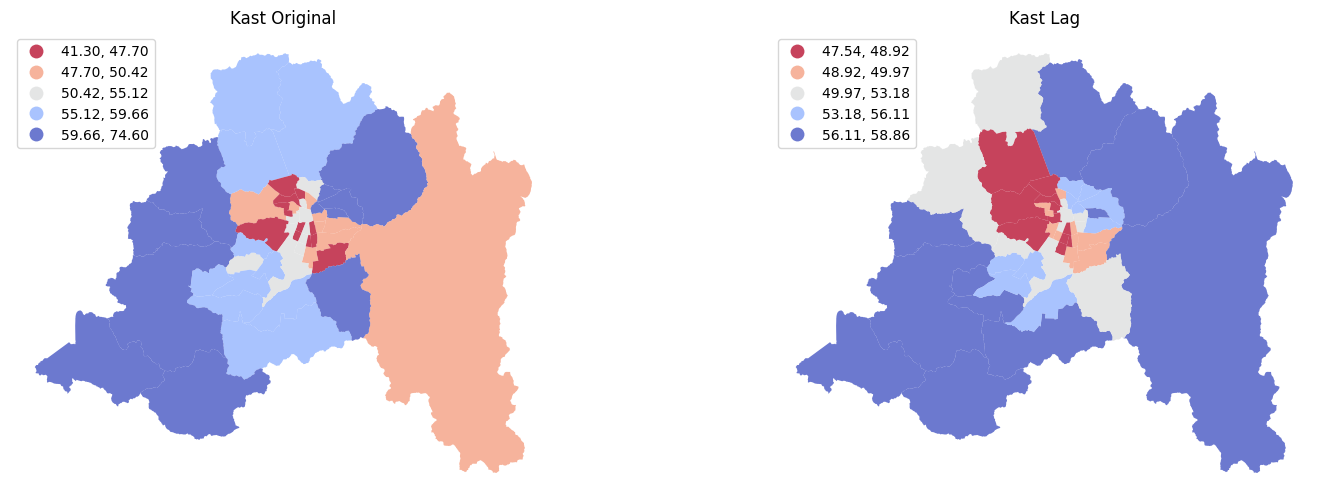

In [10]:
# Tu código aquí
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

db.plot(
    column="Pct_Kast",
    cmap="coolwarm_r",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=axes[0]
)
axes[0].set_axis_off()
axes[0].set_title("Kast Original")

db.plot(
    column="Pct_Kast_lag",
    cmap="coolwarm_r",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    legend=True,
    legend_kwds={"loc": 2},
    ax=axes[1]
)
axes[1].set_axis_off()
axes[1].set_title("Kast Lag")

**2.4** ¿Qué efecto produce el rezago espacial sobre las diferencias del mapa original? ¿En qué zonas las comunas 'se parecen más' a sus vecinas y en qué zonas hay discrepancias?

**Respuesta:**

El rezago espacial hace que haya una agrupación mas notoria en las preferencias de las elecciones. Algunas comunas cambiaron su "elección", como en la zona nor-poniente, que originalmente estaban inclinadas hacia Kast, pero luego del rezago pasaron a estar neutrales o a favor de jara, esto debido a que el promedio de sus vecinos apoyaban a jara. Caso contrario ocurrio en comunas del sector sur-oriente, tenian una leve incinación hacia Jara, pero al ser ponderadas con sus vecinos pasaron a tener una tendencia a favor de Kast.


---
## Ejercicio 3 — Caso binario: Join Counts (10 min)

**3.1** Crea una variable binaria `Kast_bin` que valga `1` si `Pct_Kast > 50` y `0` en otro caso. Dibuja el mapa binario.


In [11]:
# Tu código aquí
db['Kast_bin'] = np.where(db['Pct_Kast'] > 50, 1, 0)
db.head()

,REGION,NOM_REGION,PROVINCIA,NOM_PROVIN,COMUNA,NOM_COMUNA,SHAPE_Leng,SHAPE_Area,geometry,Pct_Kast,Pct_Jara,Ganador,Pct_Kast_lag,Kast_bin
0,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13404,PAINE,1.625330,0.066035,"POLYGON ((-7861259.009 -3993686.828, -7861171....",58.9,41.1,Kast,56.1875,1
1,13,REGIÓN METROPOLITANA DE SANTIAGO,134,MAIPO,13402,BUIN,0.884164,0.021166,"POLYGON ((-7862709.076 -3981412.946, -7862726....",58.4,41.6,Kast,55.1750,1
2,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13124,PUDAHUEL,0.720176,0.019124,"POLYGON ((-7880210.72 -3943389.761, -7880111.0...",48.6,51.4,Jara,48.6250,0
3,13,REGIÓN METROPOLITANA DE SANTIAGO,131,SANTIAGO,13103,CERRO NAVIA,0.170180,0.001076,"POLYGON ((-7872433.476 -3950297.697, -7872390....",42.3,57.7,Jara,49.6750,0
4,13,REGIÓN METROPOLITANA DE SANTIAGO,133,CHACABUCO,13301,COLINA,1.692007,0.093820,"POLYGON ((-7858744.468 -3888851.67, -7858792.1...",57.6,42.4,Kast,57.0250,1


Text(0.5, 1.0, 'Kast Binario')

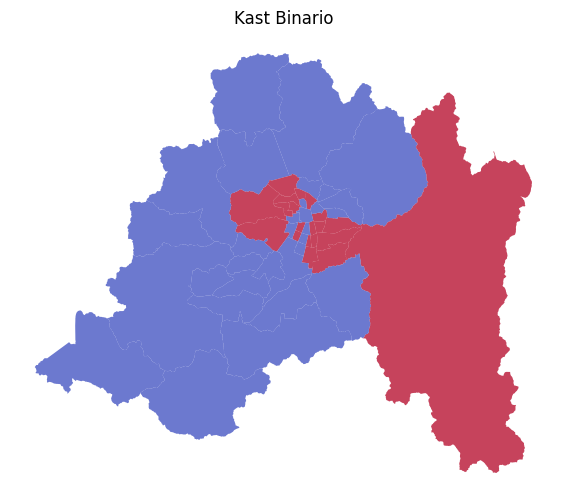

In [12]:
fig, ax = plt.subplots(1, figsize=(18, 6))

db.plot(
    column="Kast_bin",
    cmap="coolwarm_r",
    edgecolor="white",
    linewidth=0.0,
    alpha=0.75,
    ax=ax
)
ax.set_axis_off()
ax.set_title("Kast Binario")

**3.2** Construye una **matriz de pesos binaria** (sin estandarizar) con el mismo criterio KNN(k=8) y calcula el estadístico **Join Counts** con `esda.join_counts.Join_Counts(Kast_bin, w_bin)`. Imprime conteos observados (BB, WW, BW) y pseudo p-valores.


In [13]:
# Tu código aquí
w.transform = "O"
estadistico_join_counts = esda.join_counts.Join_Counts(db["Kast_bin"], w)

print(f"Uniones GG (0-0): {estadistico_join_counts.bb}")
print(f"Uniones AA (1-1): {estadistico_join_counts.ww}")
print(f"Uniones GA (0-1): {estadistico_join_counts.bw}")
print(f"Total de uniones: {estadistico_join_counts.J}")

print(f"Uniones GG esperadas: {estadistico_join_counts.mean_bb:.1f}")
print(f"Uniones GA esperadas: {estadistico_join_counts.mean_bw:.1f}")

print(f"P-valor para uniones misma categoría (GG): {estadistico_join_counts.p_sim_bb:.4f}")
print(f"P-valor para uniones distinta categoría (GA): {estadistico_join_counts.p_sim_bw:.4f}")

Uniones GG (0-0): 76.0
Uniones AA (1-1): 50.5
Uniones GA (0-1): 81.5
Total de uniones: 208.0
Uniones GG esperadas: 73.2
Uniones GA esperadas: 102.0
P-valor para uniones misma categoría (GG): 0.2770
P-valor para uniones distinta categoría (GA): 0.9990


**3.3** ¿Qué indica el resultado? ¿Hay más uniones BB o WW de lo esperado bajo aleatoriedad? ¿Puedes concluir si existe clustering binario del voto Kast?

**Respuesta:**


Este resultado muestra que la union mas común es la de Kast-Jara, sin embargo esta muestra se esperaba que fuese superior.
La unión Kast-Kast igualmente se esperaba que fuese superior, mientras que la unión Jara-Jara fue la menos representada.

Tanto la categoria Kast-Kast como Kast-Jara se esperaban que fuesen superior, sin embargo el hecho de que sean inferiores a los esperados "tiene sentido", debido a los p-valores obtenidos. Los p-valores son altos, lo cual representa que los datos tienen una alta componente de aleatoriedad.


---
## Ejercicio 4 — Caso continuo: I de Moran y C de Geary (15 min)

**4.1** Centra `Pct_Kast` restándole su media y guárdalo como `Pct_Kast_std`. Calcula su rezago espacial y guárdalo como `Pct_Kast_lag_std`.


In [14]:
# Tu código aquí
db["Pct_Kast_std"] = db["Pct_Kast"] - db["Pct_Kast"].mean()

db["Pct_Kast_lag_std"] = weights.lag_spatial(
    w, db["Pct_Kast_std"]
)

**4.2** Dibuja el **Gráfico de Moran** usando `seaborn.regplot` (eje X: `Pct_Kast_std`, eje Y: `Pct_Kast_lag_std`). Agrega líneas horizontales y verticales en 0 para marcar los cuatro cuadrantes.


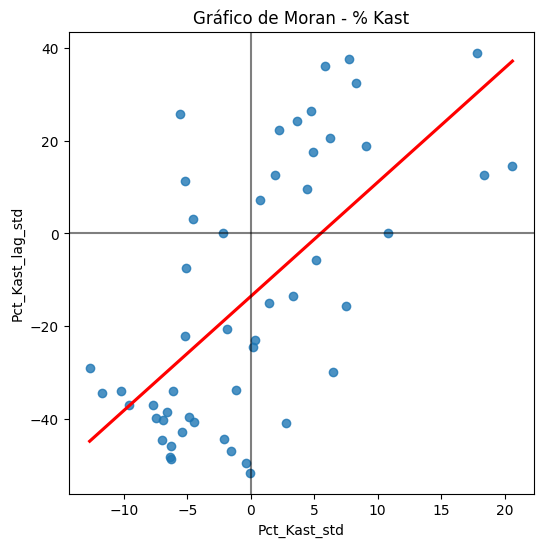

In [15]:
# Tu código aquí
f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="Pct_Kast_std",
    y="Pct_Kast_lag_std",
    ci=None,
    data=db,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Gráfico de Moran - % Kast")
plt.show()

**4.3** Calcula formalmente el **I de Moran** con `esda.moran.Moran` e imprime su valor y pseudo p-valor. Luego usa `splot.esda.plot_moran` para ver la distribución de permutaciones.


In [16]:
# Tu código aquí
w.transform = "R"
moran = esda.moran.Moran(db["Pct_Kast"], w)
print(f"I de Moran: {moran.I:.4f}")
print(f"Pseudo p-valor: {moran.p_sim:.4f}")

I de Moran: 0.3078
Pseudo p-valor: 0.0010


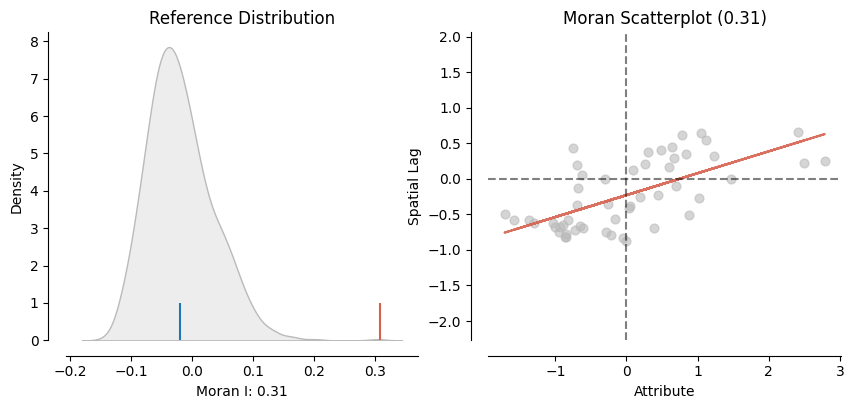

In [17]:
splot.esda.plot_moran(moran)
plt.show()

**4.4** Calcula el **C de Geary** con `esda.geary.Geary` e imprime su valor y pseudo p-valor.


In [18]:
# Tu código aquí
geary = esda.geary.Geary(db["Pct_Kast"], w)

print(f"C de Geary: {geary.C:.4f}")
print(f"Pseudo p-valor: {geary.p_sim:.4f}")

C de Geary: 0.6180
Pseudo p-valor: 0.0010


**4.5** Interpreta y compara:

- ¿Qué signo tiene el I de Moran? ¿Confirma lo que veías en el mapa?
- ¿El C de Geary es consistente con el I de Moran? Recuerda que la interpretación es inversa: valores < 1 indican clustering.
- ¿Qué comuna (o pocas) destacan en el gráfico de Moran como **outliers espaciales** (cuadrantes alto-bajo o bajo-alto)?

**Respuesta:**

El Indice de Moran tiene signo positivo, lo cual representa una autocorrelación positiva, es decir que los valores similares se agrupan. Esto confirma lo visto en el mapa, con comunas de valores iguales están juntas (comunas que votan Kast están juntas.)
El indice de Geary es consistente con el I de Moran, porque al ser menor a 1 también representa una autocorrelación positiva, los vecinos son similares y esto indica que si hubo clustering.

Comunas como Peñalolen o Recoleta se encuentran en el cuadrante bajo-alto del gráfico y podemos notarlo en nuestro gráfico binario que tienen vecinos distintos donde la opción que ganó es distinta.

---
## Ejercicio 5 — G de Getis-Ord y hot spots (15 min)

**5.1** Reproyecta `db` al CRS UTM 19S (`epsg=32719`) para trabajar con distancias en metros. Calcula los centroides y el umbral mínimo de distancia con `weights.util.min_threshold_distance`.


In [ ]:
# Tu código aquí
# Reproyectar
db_osgb = db.to_crs(epsg=27700)

pts = db_osgb.centroid
xys = pandas.DataFrame({"X": pts.x, "Y": pts.y})

# Distancia umbral minima
min_thr = weights.util.min_threshold_distance(xys)
print(f"Distancia umbral mínima: {min_thr:,.0f} m")

Distancia umbral mínima: 59,846 m


**5.2** Construye la matriz `w_db` con `weights.DistanceBand.from_dataframe` y calcula el **G de Getis-Ord global** con `esda.getisord.G(db["Pct_Kast"], w_db)`. Imprime G y pseudo p-valor. Interprete.


In [ ]:
# Tu código aquí
w_db = weights.DistanceBand.from_dataframe(db_osgb, min_thr)
gao = esda.getisord.G(db["Pct_Kast"], w_db)

In [ ]:
# Tu código aquí
print(f"G de Getis-Ord: {gao.G:.6f}")
print(f"Pseudo p-valor: {gao.p_sim:.4f}")

G de Getis-Ord: 0.620740
Pseudo p-valor: 0.0060
